In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

from fpl_project.scripts import config
from fpl_project.scripts.data_utils.features_processing import FeatureEngineer
from fpl_project.scripts.data_utils.features_config import FeaturesConfig

In [4]:
data = pd.read_parquet(config.TIDY_DATA_PATH).reset_index(drop=True)

FileNotFoundError: [Errno 2] No such file or directory: '/opt/python/lib/python3.13/Data/tidy_data.parquet'

In [ ]:
data.total_points = data.total_points.clip(lower=0)

In [16]:
data.columns

Index(['name', 'position', 'team', 'xP', 'assists', 'bonus', 'bps',
       'clean_sheets', 'creativity', 'element', 'xa', 'xg_involvements', 'xg',
       'xg_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index',
       'influence', 'kickoff_time', 'minutes', 'own_goals', 'penalties_missed',
       'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'starts',
       'team_a_score', 'team_h_score', 'threat', 'total_points',
       'transfers_balance', 'transfers_in', 'transfers_out', 'value',
       'yellow_cards', 'season', 'gw', 'code', 'date', 'opponent_team',
       'was_home', 'prob_win', 'prob_draw', 'prob_lose', 'prob_over_2.5',
       'prob_under_2.5', 'elo', 'xa_per_90', 'xg_involvements_per_90',
       'xg_per_90', 'xg_conceded_per_90'],
      dtype='object')

In [17]:
def numpy_dtypes(df:pd.DataFrame)->pd.DataFrame:
    df = df.copy()
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].astype(np.float64)

    return df

In [18]:
data = numpy_dtypes(data)

In [19]:
data.dtypes.head()

name         object
position     object
team         object
xP          float64
assists     float64
dtype: object

In [20]:
data.columns = data.columns.str.lower()

In [21]:
import pandas as pd

def add_elo_opp_feature(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    elo_lookup = df[['kickoff_time', 'team', 'elo']].drop_duplicates()

    df = pd.merge(
        df,
        elo_lookup,
        left_on=['kickoff_time', 'opponent_team'],
        right_on=['kickoff_time', 'team'],
        how='left',
        suffixes=('', '_opp')

    )
    if 'team_opp' in df.columns:
        df.drop(columns=['team_opp'], inplace=True)

    return df


In [22]:
data = add_elo_opp_feature(data)
data.elo_opp

0         1756.861572
1         1868.482422
2         1720.797974
3         1832.020386
4         2071.110107
             ...     
113265    1677.933105
113266    1888.472656
113267    1829.104614
113268    1888.908691
113269    1832.302734
Name: elo_opp, Length: 113270, dtype: float64

In [23]:
data.columns

Index(['name', 'position', 'team', 'xp', 'assists', 'bonus', 'bps',
       'clean_sheets', 'creativity', 'element', 'xa', 'xg_involvements', 'xg',
       'xg_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index',
       'influence', 'kickoff_time', 'minutes', 'own_goals', 'penalties_missed',
       'penalties_saved', 'red_cards', 'round', 'saves', 'selected', 'starts',
       'team_a_score', 'team_h_score', 'threat', 'total_points',
       'transfers_balance', 'transfers_in', 'transfers_out', 'value',
       'yellow_cards', 'season', 'gw', 'code', 'date', 'opponent_team',
       'was_home', 'prob_win', 'prob_draw', 'prob_lose', 'prob_over_2.5',
       'prob_under_2.5', 'elo', 'xa_per_90', 'xg_involvements_per_90',
       'xg_per_90', 'xg_conceded_per_90', 'elo_opp'],
      dtype='object')

In [24]:
data.drop(columns=["fixture", "round", "date", ], inplace=True)

In [25]:
#data.drop(columns=["understat", "date"], inplace=True)

In [26]:
data.head()

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,own_goals,penalties_missed,penalties_saved,red_cards,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,yellow_cards,season,gw,code,opponent_team,was_home,prob_win,prob_draw,prob_lose,prob_over_2.5,prob_under_2.5,elo,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90,elo_opp
0,Andy Lonergan,GK,Everton,1.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-04-22,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,2223.0,32.0,11948.0,Crystal Palace,False,0.250399,0.295085,0.454516,0.406091,0.593909,1668.829956,0.0,0.0,0.0,0.0,1756.861572
1,Andy Lonergan,GK,Everton,-0.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-04-27,0.0,0.0,0.0,0.0,0.0,0.0,1.932986e-07,0.0,4.0,1.0,0.0,0.0,17.0,18.0,1.0,4.0,0.0,2223.0,33.0,11948.0,Newcastle,True,0.198312,0.259413,0.542276,0.467363,0.532637,1672.510376,0.0,0.0,0.0,0.0,1868.482422
2,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,0.0,0.0,0.0,0.0,0.0,0.0,3.452826e-07,0.0,2.0,2.0,0.0,0.0,19.0,25.0,6.0,4.0,0.0,2223.0,34.0,11948.0,Leicester,False,0.252755,0.277665,0.469580,0.471204,0.528796,1664.741699,0.0,0.0,0.0,0.0,1720.797974
3,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-08,0.0,0.0,0.0,0.0,0.0,0.0,6.484797e-07,0.0,5.0,1.0,0.0,0.0,11.0,32.0,21.0,4.0,0.0,2223.0,35.0,11948.0,Brighton,False,0.112712,0.180126,0.707162,0.599496,0.400504,1667.643433,0.0,0.0,0.0,0.0,1832.020386
4,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-14,0.0,0.0,0.0,0.0,0.0,0.0,6.562414e-07,0.0,3.0,0.0,0.0,0.0,-3.0,22.0,25.0,4.0,0.0,2223.0,36.0,11948.0,Man City,True,0.108515,0.184539,0.706946,0.580563,0.419437,1694.991699,0.0,0.0,0.0,0.0,2071.110107


In [27]:
data.isna().sum().sum()

np.int64(0)

In [28]:
data["transfers_trend"] = (data.transfers_balance / data.selected).replace([np.inf, -np.inf], np.nan).fillna(0)
data["elo_diff"] = data.elo - data.elo_opp
data['prob_win_elo'] = 1 / (1 + 10 ** ((data['elo_opp'] - data['elo']) / 400))

In [29]:
data['player_match_xg_expected'] = data['xg_per_90'] * data['prob_win'] * data['prob_over_2.5']
data['player_match_xa_expected'] = data['xa_per_90'] * data['prob_win'] * data['prob_over_2.5']
data['match_value_efficiency'] = (data['prob_win'] + (0.5 * data['prob_draw'])) / data['value']
data['hype_vs_odds_ratio'] = data['transfers_trend'] / (data['prob_win'] + 0.01)

In [30]:
data.columns

Index(['name', 'position', 'team', 'xp', 'assists', 'bonus', 'bps',
       'clean_sheets', 'creativity', 'element', 'xa', 'xg_involvements', 'xg',
       'xg_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
       'influence', 'kickoff_time', 'minutes', 'own_goals', 'penalties_missed',
       'penalties_saved', 'red_cards', 'saves', 'selected', 'starts',
       'team_a_score', 'team_h_score', 'threat', 'total_points',
       'transfers_balance', 'transfers_in', 'transfers_out', 'value',
       'yellow_cards', 'season', 'gw', 'code', 'opponent_team', 'was_home',
       'prob_win', 'prob_draw', 'prob_lose', 'prob_over_2.5', 'prob_under_2.5',
       'elo', 'xa_per_90', 'xg_involvements_per_90', 'xg_per_90',
       'xg_conceded_per_90', 'elo_opp', 'transfers_trend', 'elo_diff',
       'prob_win_elo', 'player_match_xg_expected', 'player_match_xa_expected',
       'match_value_efficiency', 'hype_vs_odds_ratio'],
      dtype='object')

In [31]:
data.columns

Index(['name', 'position', 'team', 'xp', 'assists', 'bonus', 'bps',
       'clean_sheets', 'creativity', 'element', 'xa', 'xg_involvements', 'xg',
       'xg_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
       'influence', 'kickoff_time', 'minutes', 'own_goals', 'penalties_missed',
       'penalties_saved', 'red_cards', 'saves', 'selected', 'starts',
       'team_a_score', 'team_h_score', 'threat', 'total_points',
       'transfers_balance', 'transfers_in', 'transfers_out', 'value',
       'yellow_cards', 'season', 'gw', 'code', 'opponent_team', 'was_home',
       'prob_win', 'prob_draw', 'prob_lose', 'prob_over_2.5', 'prob_under_2.5',
       'elo', 'xa_per_90', 'xg_involvements_per_90', 'xg_per_90',
       'xg_conceded_per_90', 'elo_opp', 'transfers_trend', 'elo_diff',
       'prob_win_elo', 'player_match_xg_expected', 'player_match_xa_expected',
       'match_value_efficiency', 'hype_vs_odds_ratio'],
      dtype='object')

In [32]:
data.shape

(113270, 59)

In [33]:
cols_map = FeaturesConfig()

In [34]:
target = getattr(cols_map, "target")

id_cols = getattr(cols_map, "id_cols")

static_cols = ["position", "was_home", "starts"]

fpl_cols = ["bonus", "bps", "ict_index", "influence", "value", "threat"] + list(set([c for c in data.columns if "transfers" in c or "selected" in c]))

perf_cols = list(set([c for c in data.columns if c not in target + id_cols + static_cols + fpl_cols]))

In [34]:
data

In [35]:
data.shape[1], len(cols_map.target + cols_map.id_cols + cols_map.static_cols + cols_map.fpl_cols + cols_map.perf_cols)

(59, 62)

In [37]:
[c for c in data.columns if c not in cols_map.target + cols_map.id_cols + cols_map.static_cols + cols_map.fpl_cols + cols_map.perf_cols]

[]

In [38]:
feature_eng = FeatureEngineer(df=data)
LAG_SIZE = [1, 2, 3, 5]
WINDOW_SIZE = [3, 5, 8]
STD_SIZE = WINDOW_SIZE
data_lag = feature_eng.features_integration(lag_size=LAG_SIZE, window_size=WINDOW_SIZE, std_size=STD_SIZE)

In [39]:
data_lag.head()

,prob_under_2.5,prob_win_elo,match_value_efficiency,team,player_match_xg_expected,transfers_out,hype_vs_odds_ratio,transfers_balance,kickoff_time,transfers_trend,prob_draw,elo_opp,element,prob_lose,elo,player_match_xa_expected,transfers_in,name,selected,value,prob_over_2.5,code,prob_win,gw,season,opponent_team,elo_diff,position,was_home,total_points,bonus_ema_3,bps_ema_3,ict_index_ema_3,influence_ema_3,threat_ema_3,creativity_ema_3,value_ema_3,selected_ema_3,transfers_in_ema_3,transfers_out_ema_3,transfers_balance_ema_3,transfers_trend_ema_3,goals_scored_ema_3,assists_ema_3,own_goals_ema_3,penalties_missed_ema_3,xg_ema_3,xa_ema_3,xg_per_90_ema_3,xa_per_90_ema_3,xg_involvements_ema_3,xg_involvements_per_90_ema_3,goals_conceded_ema_3,xg_conceded_ema_3,xg_conceded_per_90_ema_3,clean_sheets_ema_3,saves_ema_3,penalties_saved_ema_3,minutes_ema_3,yellow_cards_ema_3,red_cards_ema_3,team_h_score_ema_3,team_a_score_ema_3,xp_ema_3,prob_win_ema_3,prob_draw_ema_3,prob_lose_ema_3,prob_over_2.5_ema_3,prob_under_2.5_ema_3,elo_ema_3,elo_opp_ema_3,elo_diff_ema_3,prob_win_elo_ema_3,player_match_xg_expected_ema_3,player_match_xa_expected_ema_3,match_value_efficiency_ema_3,hype_vs_odds_ratio_ema_3,total_points_ema_3,bonus_ema_5,bps_ema_5,ict_index_ema_5,influence_ema_5,threat_ema_5,creativity_ema_5,value_ema_5,selected_ema_5,transfers_in_ema_5,transfers_out_ema_5,transfers_balance_ema_5,transfers_trend_ema_5,goals_scored_ema_5,assists_ema_5,own_goals_ema_5,penalties_missed_ema_5,xg_ema_5,xa_ema_5,xg_per_90_ema_5,xa_per_90_ema_5,xg_involvements_ema_5,xg_involvements_per_90_ema_5,goals_conceded_ema_5,xg_conceded_ema_5,xg_conceded_per_90_ema_5,clean_sheets_ema_5,saves_ema_5,penalties_saved_ema_5,minutes_ema_5,yellow_cards_ema_5,red_cards_ema_5,team_h_score_ema_5,team_a_score_ema_5,xp_ema_5,prob_win_ema_5,prob_draw_ema_5,prob_lose_ema_5,prob_over_2.5_ema_5,prob_under_2.5_ema_5,elo_ema_5,elo_opp_ema_5,elo_diff_ema_5,prob_win_elo_ema_5,player_match_xg_expected_ema_5,player_match_xa_expected_ema_5,match_value_efficiency_ema_5,hype_vs_odds_ratio_ema_5,total_points_ema_5,bonus_ema_8,bps_ema_8,ict_index_ema_8,influence_ema_8,threat_ema_8,creativity_ema_8,value_ema_8,selected_ema_8,transfers_in_ema_8,transfers_out_ema_8,transfers_balance_ema_8,transfers_trend_ema_8,goals_scored_ema_8,assists_ema_8,own_goals_ema_8,penalties_missed_ema_8,xg_ema_8,xa_ema_8,xg_per_90_ema_8,xa_per_90_ema_8,xg_involvements_ema_8,xg_involvements_per_90_ema_8,goals_conceded_ema_8,xg_conceded_ema_8,xg_conceded_per_90_ema_8,clean_sheets_ema_8,saves_ema_8,penalties_saved_ema_8,minutes_ema_8,yellow_cards_ema_8,red_cards_ema_8,team_h_score_ema_8,team_a_score_ema_8,xp_ema_8,prob_win_ema_8,prob_draw_ema_8,prob_lose_ema_8,prob_over_2.5_ema_8,prob_under_2.5_ema_8,elo_ema_8,elo_opp_ema_8,elo_diff_ema_8,prob_win_elo_ema_8,player_match_xg_expected_ema_8,player_match_xa_expected_ema_8,match_value_efficiency_ema_8,hype_vs_odds_ratio_ema_8,total_points_ema_8,bonus_lagged_1,bps_lagged_1,ict_index_lagged_1,influence_lagged_1,threat_lagged_1,creativity_lagged_1,value_lagged_1,selected_lagged_1,transfers_in_lagged_1,transfers_out_lagged_1,transfers_balance_lagged_1,transfers_trend_lagged_1,goals_scored_lagged_1,assists_lagged_1,own_goals_lagged_1,penalties_missed_lagged_1,xg_lagged_1,xa_lagged_1,xg_per_90_lagged_1,xa_per_90_lagged_1,xg_involvements_lagged_1,xg_involvements_per_90_lagged_1,goals_conceded_lagged_1,xg_conceded_lagged_1,xg_conceded_per_90_lagged_1,clean_sheets_lagged_1,saves_lagged_1,penalties_saved_lagged_1,minutes_lagged_1,yellow_cards_lagged_1,red_cards_lagged_1,team_h_score_lagged_1,team_a_score_lagged_1,xp_lagged_1,prob_win_lagged_1,prob_draw_lagged_1,prob_lose_lagged_1,prob_over_2.5_lagged_1,prob_under_2.5_lagged_1,elo_lagged_1,elo_opp_lagged_1,elo_diff_lagged_1,prob_win_elo_lagged_1,player_match_xg_expected_lagged_1,player_match_xa_expected_lagged_1,match_value_efficiency_lagged_1,hype_vs_odds_ratio_lagged_1,total_points_lagged_1,bonus_lagged_2,bps_lagged_2,ict_index_lagged_2,influ

In [40]:
data_lag.isna().sum().sum()

np.int64(0)

In [41]:
data_lag.shape

(113270, 510)

In [42]:
len(data_lag.columns), len(set(data_lag.columns))

(510, 510)

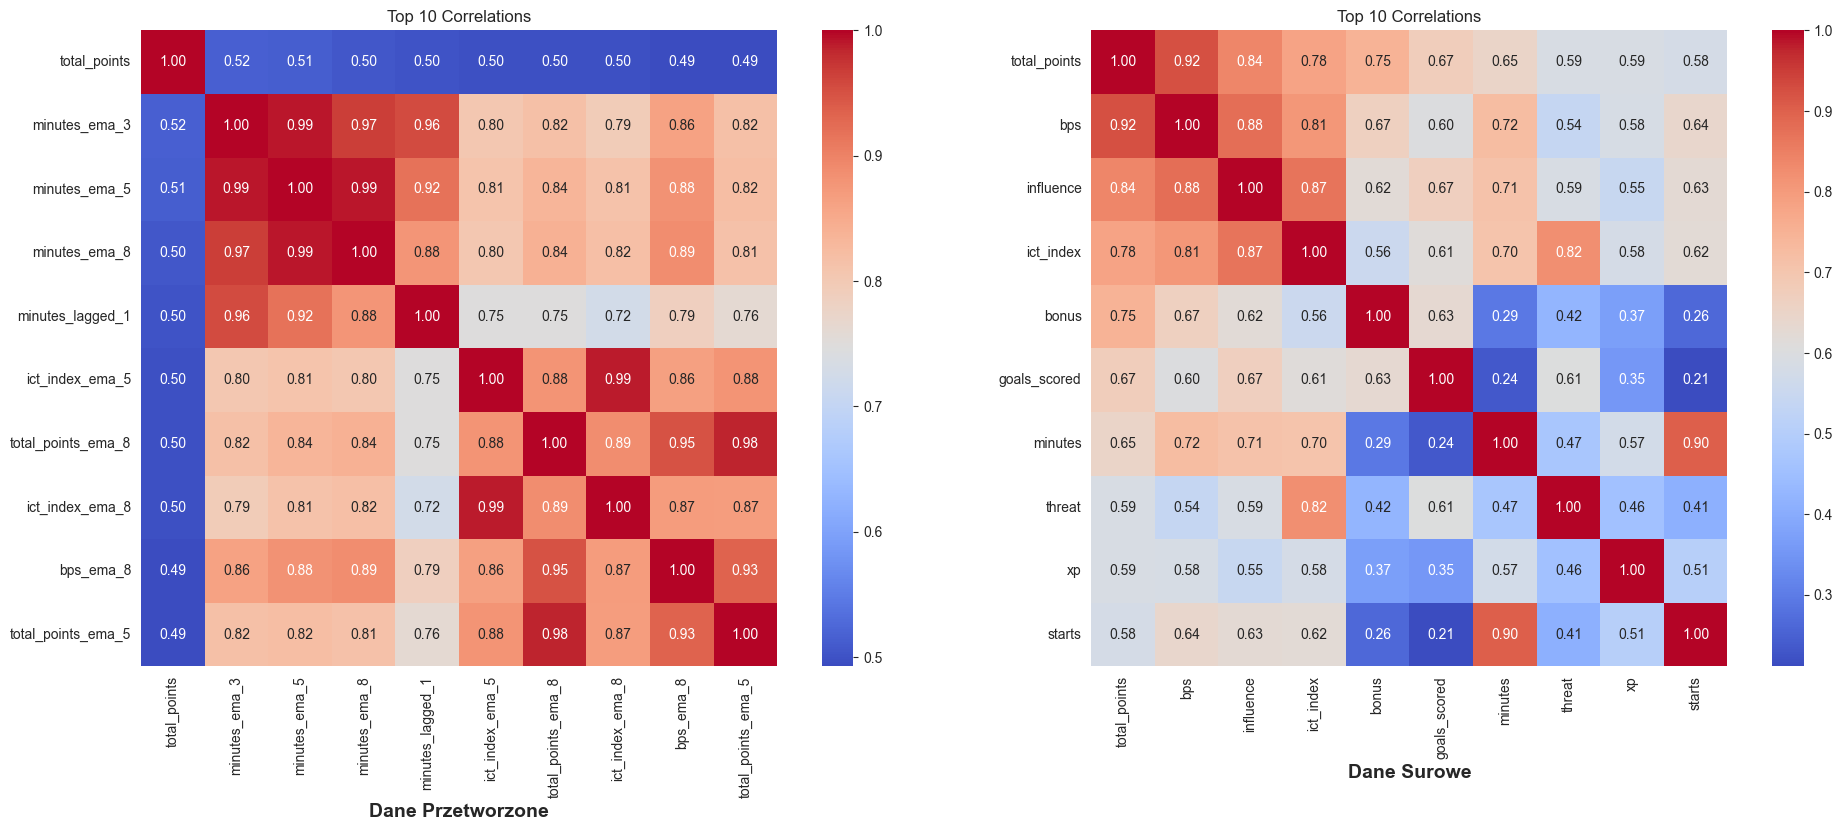

In [43]:
def corr_heatmaps(frames: list[pd.DataFrame], titles: list[str]) -> plt.Figure:
    fig, axes = plt.subplots(1, len(frames), figsize=(10 * len(frames), 8))
    if len(frames) == 1: axes = [axes]

    for ax, df, title in zip(axes, frames, titles):
        top_cols = df.select_dtypes(include=np.number).corr()["total_points"].abs().nlargest(10).index

        sns.heatmap(df[top_cols].corr(), annot=True, cmap="coolwarm", ax=ax,
                    square=True, fmt=".2f")

        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.set_title(f"Top 10 Correlations")
        ax.set_xlabel(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

fig = corr_heatmaps([data_lag, data], ["Dane Przetworzone", "Dane Surowe"])

In [44]:
def over_corr_pairs(df: pd.DataFrame, threshold: float = 0.9) -> list[tuple[str, str, float]]:
    corr_matrix = df.drop(columns=["total_points"], errors="ignore").select_dtypes(include=np.number).corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    pairs = []
    for col in upper_tri.columns:
        correlated_with = upper_tri[col][upper_tri[col] > threshold]
        for idx, val in correlated_with.items():
            pairs.append((idx, col, round(val, 4)))

    return pairs


In [45]:
pairs_list = over_corr_pairs(data_lag, threshold=0.9)
pairs = pd.DataFrame(pairs_list)

if not pairs.empty:
    cols_to_drop = pairs[1].unique()
    data_lag.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    print(f"Usunięto {len(cols_to_drop)} silnie skorelowanych kolumn.")
else:
    print("Nie znaleziono silnie skorelowanych kolumn do usunięcia.")

Usunięto 173 silnie skorelowanych kolumn.


In [46]:
data_lag

,prob_under_2.5,prob_win_elo,match_value_efficiency,team,player_match_xg_expected,transfers_out,hype_vs_odds_ratio,transfers_balance,kickoff_time,transfers_trend,prob_draw,elo_opp,element,prob_lose,elo,player_match_xa_expected,transfers_in,name,selected,value,code,gw,season,opponent_team,position,was_home,total_points,bonus_ema_3,bps_ema_3,ict_index_ema_3,threat_ema_3,creativity_ema_3,value_ema_3,transfers_in_ema_3,transfers_out_ema_3,transfers_balance_ema_3,transfers_trend_ema_3,goals_scored_ema_3,assists_ema_3,own_goals_ema_3,penalties_missed_ema_3,xg_ema_3,xa_ema_3,xg_per_90_ema_3,xa_per_90_ema_3,xg_involvements_per_90_ema_3,goals_conceded_ema_3,xg_conceded_ema_3,xg_conceded_per_90_ema_3,clean_sheets_ema_3,saves_ema_3,penalties_saved_ema_3,minutes_ema_3,yellow_cards_ema_3,red_cards_ema_3,team_h_score_ema_3,team_a_score_ema_3,xp_ema_3,prob_win_ema_3,prob_draw_ema_3,prob_lose_ema_3,prob_over_2.5_ema_3,elo_ema_3,elo_diff_ema_3,player_match_xg_expected_ema_3,player_match_xa_expected_ema_3,match_value_efficiency_ema_3,hype_vs_odds_ratio_ema_3,bonus_lagged_1,transfers_balance_lagged_1,transfers_trend_lagged_1,goals_scored_lagged_1,assists_lagged_1,own_goals_lagged_1,penalties_missed_lagged_1,xg_lagged_1,xa_lagged_1,xg_per_90_lagged_1,xa_per_90_lagged_1,xg_involvements_per_90_lagged_1,goals_conceded_lagged_1,xg_conceded_per_90_lagged_1,clean_sheets_lagged_1,penalties_saved_lagged_1,yellow_cards_lagged_1,red_cards_lagged_1,team_h_score_lagged_1,team_a_score_lagged_1,player_match_xg_expected_lagged_1,player_match_xa_expected_lagged_1,hype_vs_odds_ratio_lagged_1,bonus_lagged_2,bps_lagged_2,ict_index_lagged_2,influence_lagged_2,threat_lagged_2,creativity_lagged_2,value_lagged_2,transfers_in_lagged_2,transfers_out_lagged_2,transfers_balance_lagged_2,transfers_trend_lagged_2,goals_scored_lagged_2,assists_lagged_2,own_goals_lagged_2,penalties_missed_lagged_2,xg_lagged_2,xa_lagged_2,xg_per_90_lagged_2,xa_per_90_lagged_2,xg_involvements_lagged_2,xg_involvements_per_90_lagged_2,goals_conceded_lagged_2,xg_conceded_lagged_2,xg_conceded_per_90_lagged_2,clean_sheets_lagged_2,saves_lagged_2,penalties_saved_lagged_2,minutes_lagged_2,yellow_cards_lagged_2,red_cards_lagged_2,team_h_score_lagged_2,team_a_score_lagged_2,xp_lagged_2,prob_win_lagged_2,prob_draw_lagged_2,prob_lose_lagged_2,prob_over_2.5_lagged_2,elo_lagged_2,elo_diff_lagged_2,player_match_xg_expected_lagged_2,player_match_xa_expected_lagged_2,match_value_efficiency_lagged_2,hype_vs_odds_ratio_lagged_2,bonus_lagged_3,bps_lagged_3,ict_index_lagged_3,influence_lagged_3,threat_lagged_3,creativity_lagged_3,value_lagged_3,transfers_in_lagged_3,transfers_out_lagged_3,transfers_balance_lagged_3,transfers_trend_lagged_3,goals_scored_lagged_3,assists_lagged_3,own_goals_lagged_3,penalties_missed_lagged_3,xg_lagged_3,xa_lagged_3,xg_per_90_lagged_3,xa_per_90_lagged_3,xg_involvements_lagged_3,xg_involvements_per_90_lagged_3,goals_conceded_lagged_3,xg_conceded_lagged_3,xg_conceded_per_90_lagged_3,clean_sheets_lagged_3,saves_lagged_3,penalties_saved_lagged_3,minutes_lagged_3,yellow_cards_lagged_3,red_cards_lagged_3,team_h_score_lagged_3,team_a_score_lagged_3,xp_lagged_3,prob_win_lagged_3,prob_draw_lagged_3,prob_lose_lagged_3,prob_over_2.5_lagged_3,elo_diff_lagged_3,player_match_xg_expected_lagged_3,player_match_xa_expected_lagged_3,hype_vs_odds_ratio_lagged_3,bonus_lagged_5,bps_lagged_5,ict_index_lagged_5,influence_lagged_5,threat_lagged_5,creativity_lagged_5,value_lagged_5,transfers_in_lagged_5,transfers_out_lagged_5,transfers_balance_lagged_5,transfers_trend_lagged_5,goals_scored_lagged_5,assists_lagged_5,own_goals_lagged_5,penalties_missed_lagged_5,xg_lagged_5,xa_lagged_5,xg_per_90_lagged_5,xa_per_90_lagged_5,xg_involvements_lagged_5,xg_involvements_per_90_lagged_5,goals_conceded_lagged_5,xg_conceded_lagged_5,xg_conceded_per_90_lagged_5,clean_sheets_lagged_5,saves_lagged_5,penalties_saved_lagged_5,minutes_lagged_5,yellow_cards_lagged_5,red_cards_lagged_5,team_h_score_lagged_5,team_a_score_lagged_5,x

In [47]:
data_lag.shape

(113270, 337)

In [48]:
data.shape

(113270, 59)

In [49]:


data_lag.to_parquet(config.FPL_DATA_PATH,
                index=False)

In [50]:
[c for c in data_lag.columns if "min" in c]

['minutes_ema_3',
 'minutes_lagged_2',
 'minutes_lagged_3',
 'minutes_lagged_5',
 'minutes_std_3',
 'minutes_std_5',
 'minutes_std_8']

In [51]:
data.to_parquet(config.TIDY_DATA_PATH,
                index=False)